# Problem: Euler-Bernoulli Beam with uniformly distributed load and elastic support

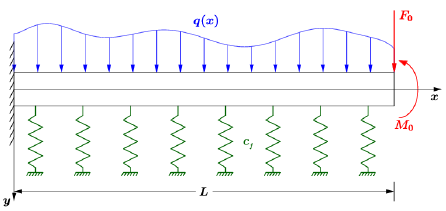

Source: *[2] Lopez (2025)*.

The PDE of the problem is:

$EIv^{IV}(x) + c_f v(x) - q(x) = 0$,

where:
- $v(x)$ is the transverse displacement of the beam,
- $E$ is the Young's modulus,
- $I$ is the moment of inertia,
- $c_f$ is the elastic stiffness of the spring,
- $q(x)$ is the distributed load, and
- $L$ is the length of the beam.

The boundary conditions are:

- $v(0) = 0$,
- $v'(0) = 0$,
- $EIv'''(L) = -F_0$, and
- $EIv''(L) = -M_0$.

Let's consider the following values:

Rectangular cross section $0.20$ m $\times 0.60$ m, length $L = 8$ m, Young's modulus $E = 200$ GPa, uniform load $q = 5$ kN/m, $F_0 = 2$ kN e $M_0 = 4$ kNm, elastic stiffness of the spring base $c_f = 4 \times 10^8$.

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sympy import symbols, simplify, Eq, solve, Derivative, dsolve, Function
from sympy import lambdify
from sympy import trigsimp, re

import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

## Exact solution

In [2]:
def get_analytical_solution(x_analytical, L_in, E_in, I_in, F0_in, M0_in, cf_in, q_in):
    # Declaração simbólica
    E, I, L, Fo, Mo, cf, q = symbols('E I L Fo Mo cf q')
    x = symbols('x', real=True)
    v = Function('v')

    # EDO simbolicamente
    edo = Eq(E*I*Derivative(v(x), x, 4) + cf*v(x), q)

    # Resolve simbolicamente
    sol_geral = dsolve(edo, v(x))
    v_gen = sol_geral.rhs

    v1 = v_gen.diff(x, 1)
    v2 = v_gen.diff(x, 2)
    v3 = v_gen.diff(x, 3)

    conds = [
        Eq(v_gen.subs(x, 0), 0),
        Eq(v1.subs(x, 0), 0),
        Eq(v2.subs(x, L), -Mo / (E * I)),
        Eq(v3.subs(x, L), -Fo / (E * I)),
    ]

    # Descobre as constantes C1, C2...
    constantes = list(v_gen.free_symbols - {x, E, I, L, Fo, Mo, cf, q})
    sol_consts = solve(conds, constantes)

    # Substitui as constantes na solução geral
    v_final = simplify(v_gen.subs(sol_consts))

    # Valores numéricos
    valores = {
        E: E_in,
        cf: cf_in,
        L: L_in,
        I: I_in,
        q: q_in,
        Fo: F0_in,
        Mo: M0_in,
    }

    v_final_n = (v_final.subs(valores))
    v_final_nu = trigsimp(v_final_n)
    v_final_num = re(v_final_nu)

    # Transformar em função para plotar
    u_func = lambdify(x, v_final_num, modules='numpy')
    y_vals = u_func(x_analytical)

    return y_vals

In [3]:
def get_analytical_solution_no_cf(x_analytical, L_in, E_in, I_in, F0_in, M0_in, q_in):
    # Declaração simbólica
    E, I, L, Fo, Mo, q = symbols('E I L Fo Mo q')
    x = symbols('x', real=True)
    v = Function('v')

    # EDO simbolicamente
    edo = Eq(E*I*Derivative(v(x), x, 4), q)

    # Resolve simbolicamente
    sol_geral = dsolve(edo, v(x))
    v_gen = sol_geral.rhs

    v1 = v_gen.diff(x, 1)
    v2 = v_gen.diff(x, 2)
    v3 = v_gen.diff(x, 3)

    conds = [
        Eq(v_gen.subs(x, 0), 0),
        Eq(v1.subs(x, 0), 0),
        Eq(v2.subs(x, L), -Mo / (E * I)),
        Eq(v3.subs(x, L), -Fo / (E * I)),
    ]

    # Descobre as constantes C1, C2...
    constantes = list(v_gen.free_symbols - {x, E, I, L, Fo, Mo, q})
    sol_consts = solve(conds, constantes)

    # Substitui as constantes na solução geral
    v_final = simplify(v_gen.subs(sol_consts))

    # Valores numéricos
    valores = {
        E: E_in,
        L: L_in,
        I: I_in,
        q: q_in,
        Fo: F0_in,
        Mo: M0_in,
    }

    v_final_n = (v_final.subs(valores))
    v_final_nu = trigsimp(v_final_n)
    v_final_num = re(v_final_nu)

    # Transformar em função para plotar
    u_func = lambdify(x, v_final_num, modules='numpy')
    y_vals = u_func(x_analytical)

    return y_vals

In [6]:
def save_checkpoint(model, filename="best_model.pth"):
    """Saves the model's state dictionary."""
    torch.save(model.state_dict(), filename)

def load_checkpoint(model, filename="best_model.pth", device="cpu"):
    """Loads the model's state dictionary."""
    print(f"Loading best model from {filename}...")
    model.load_state_dict(torch.load(filename, map_location=device))

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

L = 1.0
E = 200e9
b = 0.20
h = 0.60
I = (b * h**3) / 12
q = 5e3
cf = 0
F0 = 2e3
M0 = 4e3
EI = E * I

Using device: cuda


In [9]:
x_test = torch.linspace(0, L, 500, device=device).view(-1, 1)

In [ ]:
x_analytical = x_test.cpu().numpy().flatten()
# v_analytical = get_analytical_solution(x_analytical, L, E, I, F0, M0, cf, q)
v_analytical = get_analytical_solution_no_cf(x_analytical, L, E, I, F0, M0, q)

In [11]:
# PINN architecture
layers = [1, 64, 64, 64, 64, 64, 1]
activation = F.gelu

activations = [torch.sin, F.gelu]

# Training parameters
learning_rate = 1e-4
epochs = 20000
batch_size = 500
n_physics_points = 2000
lambda_bc = 1000.0

## gPINN with Adaptive Weights and Residual-Based Adaptive Refinement

In [12]:
class PINN(nn.Module):
    def __init__(self, layers, activation=torch.tanh):
        super(PINN, self).__init__()
        self.activation = activation
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        self.init_weights()

    def init_weights(self):
        for m in self.linears:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.dim() == 1: x = x.view(-1, 1)
        for i, layer in enumerate(self.linears[:-1]):
            x = self.activation(layer(x))
        return self.linears[-1](x)

# --- Combined Advanced PINN ---
class CombinedGatedPINN(PINN):
    def __init__(self, layers, activation=torch.tanh):
        super().__init__(layers, activation)
        # Adaptive weights (not nn.Parameters, updated manually)
        self.lambda_grad = torch.tensor(1.0)
        self.lambda_bc1 = torch.tensor(1.0)
        self.lambda_bc2 = torch.tensor(1.0)
        self.lambda_bc3 = torch.tensor(1.0)
        self.lambda_bc4 = torch.tensor(1.0)
        # EMA for the reference gradient (physics loss)
        self.grad_physics_ema = torch.tensor(0.0)

    def compute_residual(self, x, E, I, cf, q):
        x.requires_grad_(True)
        v = self.forward(x)
        v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
        v_xxx = torch.autograd.grad(v_xx, x, torch.ones_like(v_xx), create_graph=True)[0]
        v_xxxx = torch.autograd.grad(v_xxx, x, torch.ones_like(v_xxx), create_graph=True)[0]
        return E * I * v_xxxx + cf * v - q

    def get_all_losses(self, x, E, I, cf, q, L, F0, M0, device):
        """Computes all individual, unweighted loss components."""
        # Physics Loss
        residual = self.compute_residual(x, E, I, cf, q)
        loss_p = torch.mean(residual**2) / (E * I)
        
        # Gradient Loss
        grad_res = torch.autograd.grad(residual, x, torch.ones_like(residual), create_graph=True)[0]
        loss_grad = torch.mean(grad_res**2) / (E * I)
        
        # Boundary Losses
        x_0 = torch.tensor([[0.0]], requires_grad=True, device=device)
        x_L = torch.tensor([[L]], requires_grad=True, device=device)
        v_0 = self.forward(x_0)
        v_L = self.forward(x_L)
        v_x_0 = torch.autograd.grad(v_0, x_0, torch.ones_like(v_0), create_graph=True)[0]
        v_x_L = torch.autograd.grad(v_L, x_L, grad_outputs=torch.ones_like(v_L), create_graph=True)[0]
        v_xx_L = torch.autograd.grad(v_x_L, x_L, grad_outputs=torch.ones_like(v_x_L), create_graph=True)[0]
        v_xxx_L = torch.autograd.grad(v_xx_L, x_L, grad_outputs=torch.ones_like(v_xx_L), create_graph=True)[0]
        
        loss_bc1 = torch.mean(v_0**2) * E
        loss_bc2 = torch.mean(v_x_0**2) * E / I
        loss_bc3 = torch.mean((E * I * v_xx_L + M0)**2) / (E * I)
        loss_bc4 = torch.mean((E * I * v_xxx_L + F0)**2) / (E * I)

        return loss_p, loss_grad, loss_bc1, loss_bc2, loss_bc3, loss_bc4

    def update_loss_weights(self, x_physics, E, I, cf, q, L, F0, M0, device, momentum=0.9):
        """Update all lambdas based on the ratio of gradient magnitudes."""
        self.train()
        
        losses = self.get_all_losses(x_physics, E, I, cf, q, L, F0, M0, device)
        loss_p, loss_grad, loss_bc1, loss_bc2, loss_bc3, loss_bc4 = losses

        # Get gradients of physics loss (the reference)
        grad_p_list = torch.autograd.grad(loss_p, self.parameters(), allow_unused=True, retain_graph=True)
        grad_p_flat = torch.cat([g.flatten() for g in grad_p_list if g is not None])
        
        # Update EMA for the reference gradient
        mean_grad_p = torch.mean(torch.abs(grad_p_flat))
        if self.grad_physics_ema == 0.0:
            self.grad_physics_ema = mean_grad_p
        else:
            self.grad_physics_ema = momentum * self.grad_physics_ema + (1 - momentum) * mean_grad_p
        
        # Update other lambdas
        loss_terms = [loss_grad, loss_bc1, loss_bc2, loss_bc3, loss_bc4]
        lambda_attrs = ['lambda_grad', 'lambda_bc1', 'lambda_bc2', 'lambda_bc3', 'lambda_bc4']

        for i, loss_term in enumerate(loss_terms):
            grad_term_list = torch.autograd.grad(loss_term, self.parameters(), allow_unused=True, retain_graph=True)
            grad_term_flat = torch.cat([g.flatten() for g in grad_term_list if g is not None])
            mean_grad_term = torch.mean(torch.abs(grad_term_flat))
            
            if mean_grad_term > 1e-12:
                new_lambda = (self.grad_physics_ema / mean_grad_term).detach()
                setattr(self, lambda_attrs[i], new_lambda)
        
        self.zero_grad()

    def adaptive_sampling(self, x_physics, E, I, cf, q, percentile=0.1, max_points=5000):
        self.eval()
        residuals = self.compute_residual(x_physics, E, I, cf, q).abs()
        with torch.no_grad():
            threshold = torch.quantile(residuals, 1.0 - percentile)
            mask = (residuals >= threshold).squeeze()
            if mask.sum() > 0 and len(x_physics) < max_points:
                new_points = x_physics[mask] + (L * 0.05 * (torch.rand_like(x_physics[mask]) - 0.5))
                x_physics = torch.cat([x_physics, torch.clamp(new_points, 0, L)], dim=0)
                print(f"  [RAR] Added {len(new_points)} new points. Total: {len(x_physics)}")
        return x_physics

# --- Training Function ---
def train_combined_pinn(model, epochs, x_physics, batch_size, lr, device, checkpoint_path):
    histories = {'total':[], 'phys':[], 'grad':[], 'bc1':[], 'bc2':[], 'bc3':[], 'bc4':[]}
    lambda_hist = {'grad':[], 'bc1':[], 'bc2':[], 'bc3':[], 'bc4':[]}
    best_loss = float('inf')
    
    adam_epochs = int(epochs * 0.8)
    print(f"--- Phase 1: Adam Optimizer for {adam_epochs} epochs ---")
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9999)

    for epoch in range(adam_epochs):
        model.train()
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch} - Updating weights and refining points...")
            model.update_loss_weights(x_physics, E, I, cf, q, L, F0, M0, device)
            x_physics = model.adaptive_sampling(x_physics, E, I, cf, q)
            x_physics.requires_grad = True

        shuffled_indices = torch.randperm(x_physics.size(0))
        epoch_losses = {k: 0.0 for k in histories}
        n_batches = len(x_physics) // batch_size
        
        for i in range(n_batches):
            x_batch = x_physics[shuffled_indices[i*batch_size:(i+1)*batch_size]]
            optimizer_adam.zero_grad()
            
            lp, lg, lbc1, lbc2, lbc3, lbc4 = model.get_all_losses(x_batch, E, I, cf, q, L, F0, M0, device)
            
            total_loss = (lp + model.lambda_grad * lg + model.lambda_bc1 * lbc1 + 
                          model.lambda_bc2 * lbc2 + model.lambda_bc3 * lbc3 + model.lambda_bc4 * lbc4)
            
            total_loss.backward(retain_graph=True)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_adam.step()

            epoch_losses['total'] += total_loss.item()
            epoch_losses['phys'] += lp.item()
            epoch_losses['grad'] += lg.item()
            epoch_losses['bc1'] += lbc1.item()
            epoch_losses['bc2'] += lbc2.item()
            epoch_losses['bc3'] += lbc3.item()
            epoch_losses['bc4'] += lbc4.item()
        
        scheduler.step()
        
        avg_loss = epoch_losses['total'] / n_batches
        if avg_loss < best_loss:
            best_loss = avg_loss
            save_checkpoint(model, checkpoint_path)
        
        for key in histories: histories[key].append(epoch_losses[key] / n_batches)
        for key in lambda_hist: lambda_hist[key].append(getattr(model, f"lambda_{key}").item())

        if (epoch + 1) % 250 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:5d} | Avg Loss: {avg_loss:.4e} | Best: {best_loss:.4e} | "
                  f"Phys: {epoch_losses['phys'] / n_batches:.4e} | "
                  f"Grad: {epoch_losses['grad'] / n_batches:.4e} | "
                  f"BC1: {epoch_losses['bc1'] / n_batches:.4e} | "
                  f"BC2: {epoch_losses['bc2'] / n_batches:.4e} | "
                  f"BC3: {epoch_losses['bc3'] / n_batches:.4e} | "
                  f"BC4: {epoch_losses['bc4'] / n_batches:.4e}"
                  )
            print(f"lambda Grad: {lambda_hist['grad'][-1]:.4e} | "
                  f"BC1: {lambda_hist['bc1'][-1] / n_batches:.4e} | "
                  f"BC2: {lambda_hist['bc2'][-1] / n_batches:.4e} | "
                  f"BC3: {lambda_hist['bc3'][-1] / n_batches:.4e} | "
                  f"BC4: {lambda_hist['bc4'][-1] / n_batches:.4e}"
                  )

    # --- Phase 2: L-BFGS Optimizer ---
    load_checkpoint(model, checkpoint_path, device)
    model.train()
    print(f"\n--- Phase 2: L-BFGS Optimizer ---")
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500)

    loss_containers = {k: [0.0] for k in histories}
    def closure():
        optimizer_lbfgs.zero_grad()
        lp, lg, lbc1, lbc2, lbc3, lbc4 = model.get_all_losses(x_physics, E, I, cf, q, L, F0, M0, device)
        loss = (lp + model.lambda_grad * lg + model.lambda_bc1 * lbc1 + 
                model.lambda_bc2 * lbc2 + model.lambda_bc3 * lbc3 + model.lambda_bc4 * lbc4)
        loss.backward()
        loss_containers['total'][0] = loss.item()
        loss_containers['phys'][0] = lp.item()
        loss_containers['grad'][0] = lg.item()
        loss_containers['bc1'][0] = lbc1.item()
        loss_containers['bc2'][0] = lbc2.item()
        loss_containers['bc3'][0] = lbc3.item()
        loss_containers['bc4'][0] = lbc4.item()
        return loss

    optimizer_lbfgs.step(closure)
    
    final_total_loss = loss_containers['total'][0]
    if final_total_loss < best_loss: save_checkpoint(model, checkpoint_path)
    print(f"Final L-BFGS Loss: {final_total_loss:.4e}")
    for key in histories: histories[key].append(loss_containers[key][0])

    return histories, lambda_hist

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

layers = [1, 64, 64, 64, 64, 1]
model = CombinedGatedPINN(layers, activation=torch.sin).to(device)
x_physics = L * torch.rand(n_physics_points, 1, device=device)

histories, lambdas = train_combined_pinn(model, epochs, x_physics, batch_size, learning_rate, device, "best_combined_model.pth")

load_checkpoint(model, "best_combined_model.pth", device)
model.eval()

Using device: cuda
--- Phase 1: Adam Optimizer for 16000 epochs ---
Epoch 0 - Updating weights and refining points...


c:\Users\CLIENTE\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [RAR] Added 200 new points. Total: 2200
Epoch     1 | Avg Loss: 1.1190e+06 | Best: 1.1190e+06 | Phys: 4.5325e+04 | Grad: 2.1804e+05 | BC1: 2.0078e+05 | BC2: 2.1018e+11 | BC3: 6.3600e+05 | BC4: 5.3320e+05
lambda Grad: 4.5190e-01 | BC1: 2.5000e-01 | BC2: 1.5197e-07 | BC3: 8.2157e-02 | BC4: 2.0515e-01
Epoch   250 | Avg Loss: 2.0984e+04 | Best: 3.7670e+03 | Phys: 1.0292e+01 | Grad: 6.4129e+01 | BC1: 2.0940e+04 | BC2: 1.2608e+05 | BC3: 8.9419e+00 | BC4: 1.4916e+00
lambda Grad: 4.5190e-01 | BC1: 2.5000e-01 | BC2: 1.5197e-07 | BC3: 8.2157e-02 | BC4: 2.0515e-01
Epoch   500 | Avg Loss: 1.6803e+04 | Best: 3.7670e+03 | Phys: 2.3600e+00 | Grad: 4.9929e+01 | BC1: 1.6777e+04 | BC2: 3.5440e+04 | BC3: 1.1410e+00 | BC4: 4.6951e-01
lambda Grad: 4.5190e-01 | BC1: 2.5000e-01 | BC2: 1.5197e-07 | BC3: 8.2157e-02 | BC4: 2.0515e-01
Epoch 500 - Updating weights and refining points...
  [RAR] Added 220 new points. Total: 2420
Epoch   750 | Avg Loss: 3.1309e+05 | Best: 3.7670e+03 | Phys: 3.3613e+01 | Grad: 8.2

CombinedGatedPINN(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

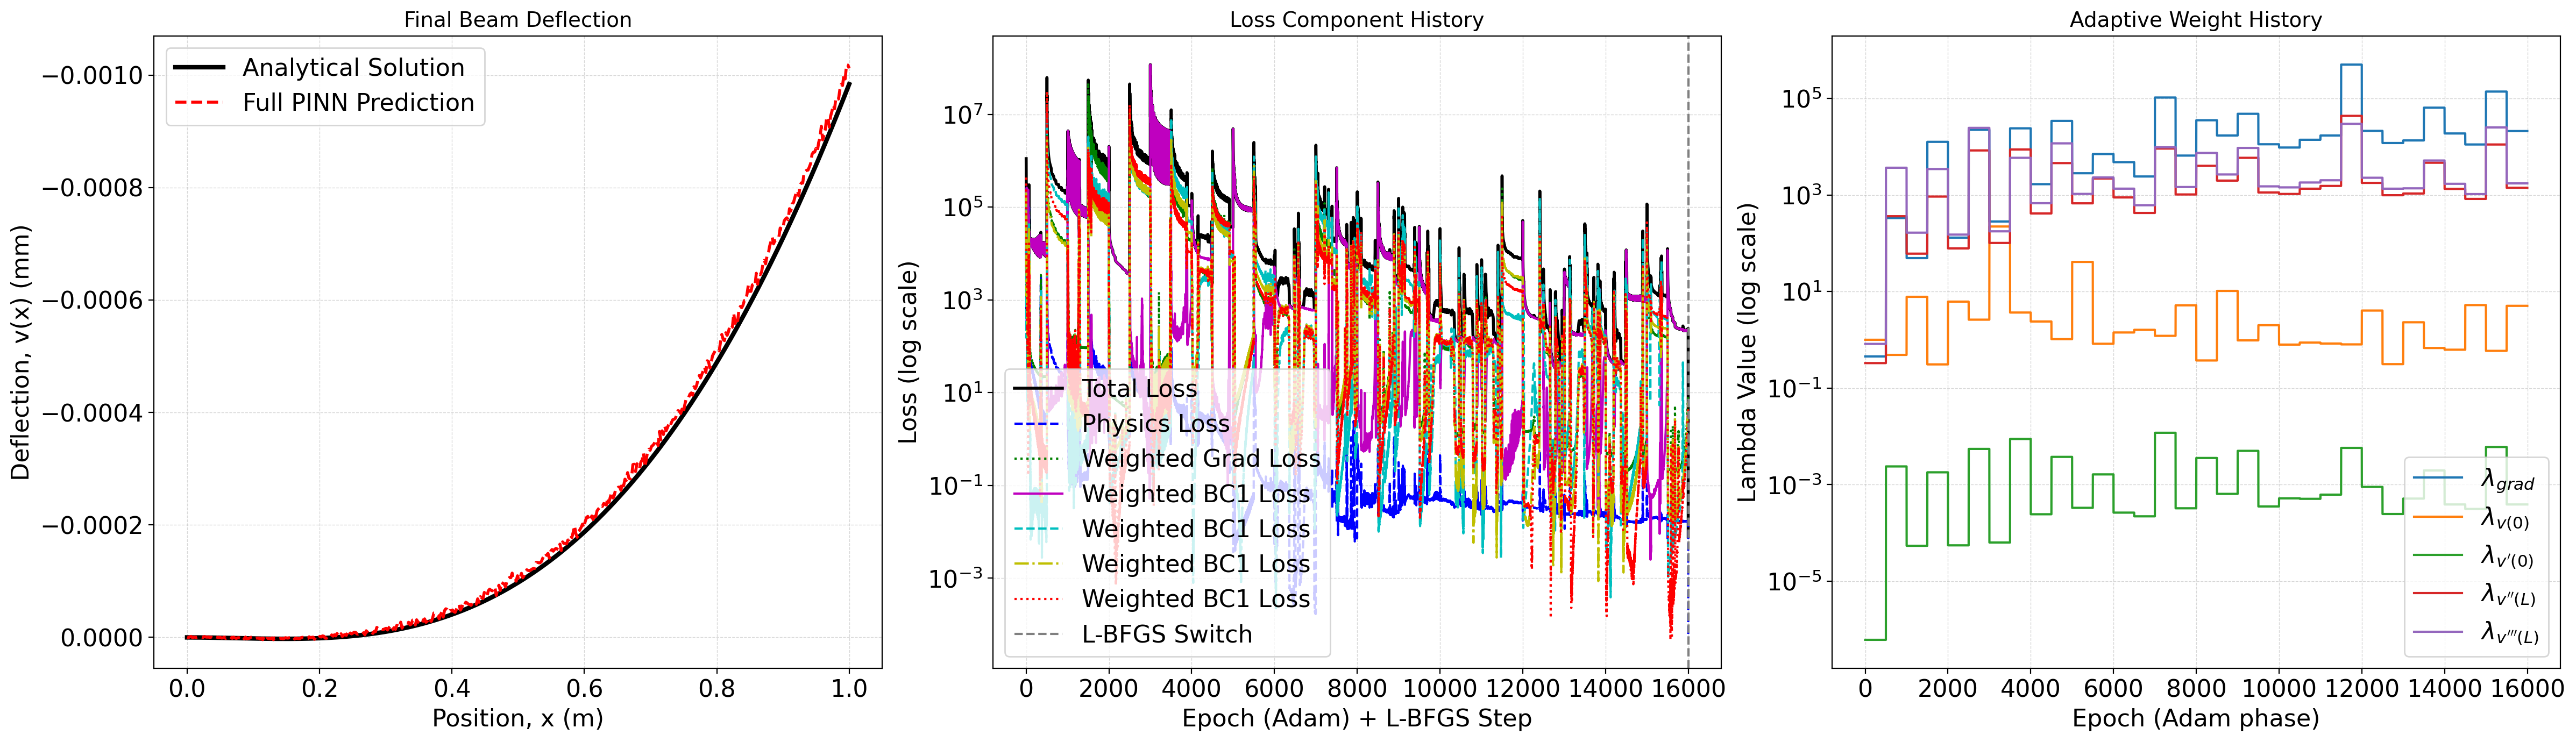

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
# Plot 1: Final Solution
x_test = torch.linspace(0, L, 500, device=device).view(-1, 1)
with torch.no_grad():
    v_pred_combined = model(x_test)

axes[0].plot(x_analytical, v_analytical * 1000, 'k-', linewidth=3, label='Analytical Solution')
axes[0].plot(x_test.cpu(), v_pred_combined.cpu() * 1000, 'r--', linewidth=2, label='Full PINN Prediction')
axes[0].set_title('Final Beam Deflection', fontsize=14)
axes[0].set_xlabel('Position, x (m)')
axes[0].set_ylabel('Deflection, v(x) (mm)')
axes[0].invert_yaxis()
axes[0].legend()
axes[0].grid(True)

# Plot 2: Loss History
adam_epochs = len(histories['total']) - 1
axes[1].semilogy(histories['total'], label='Total Loss', color='black', linewidth=2)
axes[1].semilogy(np.array(histories['phys']), label='Physics Loss', color='b', linestyle='--')
axes[1].semilogy(np.array(histories['grad'][:-1]) * np.array(lambdas['grad']), color='g', label='Weighted Grad Loss', linestyle=':')
axes[1].semilogy(np.array(histories['bc1'][:-1]) * np.array(lambdas['bc1']), color='m', label='Weighted BC1 Loss', linestyle='-')
axes[1].semilogy(np.array(histories['bc2'][:-1]) * np.array(lambdas['bc2']), color='c', label='Weighted BC1 Loss', linestyle='--')
axes[1].semilogy(np.array(histories['bc3'][:-1]) * np.array(lambdas['bc3']), color='y', label='Weighted BC1 Loss', linestyle='-.')
axes[1].semilogy(np.array(histories['bc4'][:-1]) * np.array(lambdas['bc4']), color='r', label='Weighted BC1 Loss', linestyle=':')

# Can plot other BCs if desired
axes[1].axvline(x=adam_epochs, color='grey', linestyle='--', label='L-BFGS Switch')
axes[1].set_title('Loss Component History', fontsize=14)
axes[1].set_xlabel('Epoch (Adam) + L-BFGS Step')
axes[1].set_ylabel('Loss (log scale)')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Lambda History
axes[2].semilogy(lambdas['grad'], label='$\lambda_{grad}$')
axes[2].semilogy(lambdas['bc1'], label='$\lambda_{v(0)}$')
axes[2].semilogy(lambdas['bc2'], label='$\lambda_{v\'(0)}$')
axes[2].semilogy(lambdas['bc3'], label='$\lambda_{v\'\'(L)}$')
axes[2].semilogy(lambdas['bc4'], label='$\lambda_{v\'\'\'(L)}$')
axes[2].set_title('Adaptive Weight History', fontsize=14)
axes[2].set_xlabel('Epoch (Adam phase)')
axes[2].set_ylabel('Lambda Value (log scale)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# References:
[1] Seman, Laio Oriel. Material de aula sobre PINNs. 2025.

[2] Lopez, Rafael Holdorf. Notas de aula Cálculo Variacional. Elsevier, 2020.